<img src="./logo_UNSAM.jpg" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Tarea semanal Nº 9
#### Tatiana Galansky, Guadalupe Cura


### INTRODUCCIÓN TEÓRICA
En esta actividad se estudian técnicas no lineales de estimación y sustracción del movimiento de la línea de base en registros electrocardiográficos (ECG), así como el uso de filtros adaptados para la detección de latidos. El movimiento de la línea de base consiste en oscilaciones de muy baja frecuencia (menores a 0.5 Hz) que pueden presentar alta energía, dificultando su eliminación mediante filtrado lineal clásico. Para corregir este artefacto, se estima una señal $\hat{b}[n]$ que modela dicha interferencia y se obtiene una versión filtrada del ECG mediante
$$\hat{x}[n] = s[n] - \hat{b}[n],$$
donde $s[n]$ es la señal registrada y $\hat{x}[n]$ representa la estimación del ECG libre de interferencias.
#### Estimación mediante filtro de mediana
Una primera estrategia no lineal consiste en aplicar filtros de mediana en dos etapas. Definiendo el operador $\mathrm{med}_t(\cdot)$ como la mediana sobre una ventana temporal de duración $t$, la estimación de la línea de base se expresa como
$$\hat{b}[n] = \mathrm{med}_{600}\!\left( \mathrm{med}_{200}(s[n]) \right).$$
En forma explícita, considerando una frecuencia de muestreo $f_s$, se define primero
$$m[n] = \mathrm{med}\big(s[n], s[n-1], \dots, s[n - 200 f_s]\big),$$
y luego
$$\hat{b}[n] = \mathrm{med}\big(m[n], m[n-1], \dots, m[n - 600 f_s]\big).$$
Este método elimina eficazmente componentes impulsivos o de corta duración (como el complejo QRS) preservando la tendencia de baja frecuencia asociada al movimiento de la línea de base.
#### Estimación mediante interpolación spline cúbica

Como segunda estrategia, se identifica un conjunto de instantes aproximadamente isoeléctricos asociados al intervalo PQ del ciclo cardíaco. A partir de las detecciones de latidos $n_i$, se define
$$m_i = n_i - n_0,$$
donde $n_0$ es una anticipación seleccionada para evitar incluir la onda P o Q. El conjunto de puntos de apoyo queda entonces dado por
$$S = \{(m_i, s[m_i]) \mid i = 1,2,\dots,Q\},$$
donde $Q$ es la cantidad de latidos presentes en el registro. La línea de base se estima mediante interpolación cúbica evaluada sobre todas las muestras del ECG:
$$\hat{b}(n) = \mathrm{spline3}(S,n), \qquad n = 1,2,\dots,N.$$
La señal obtenida debe estar muestreada a la misma frecuencia que $s[n]$, por lo que se realiza re-muestreo cuando sea necesario.
#### Detección de latidos mediante filtro adaptado
Para detectar latidos se emplea un filtro adaptado *matched filter* construido a partir de un patrón representativo del complejo QRS, denotado $p[n]$ de longitud $L$. La respuesta al impulso del filtro se define como la inversión temporal del patrón:
$$h[n] = p[L - 1 - n].$$
La salida del filtro corresponde a la convolución
$$ y[n] = (h * s)[n] = \sum_{k=0}^{L-1} h[k]\, s[n-k].$$
El filtro adaptado maximiza la relación señal-ruido (SNR) cuando el ruido es blanco y aditivo, generando picos pronunciados en $y[n]$ cuando el contenido de la señal coincide con el patrón QRS. La detección se realiza aplicando un umbral $T$ y un periodo refractario para evitar múltiples detecciones del mismo complejo.
#### Evaluación del desempeño
Para evaluar las detecciones se comparan los instantes estimados con los de referencia empleando una ventana de tolerancia temporal $\Delta$. A partir de los Verdaderos Positivos (TP), Falsos Positivos (FP) y Falsos Negativos (FN), se calculan métricas estándar como la sensibilidad
$$ \mathrm{Se} = \frac{\mathrm{TP}}{\mathrm{TP} + \mathrm{FN}},$$
y el valor predictivo positivo
$$\mathrm{PPV} = \frac{\mathrm{TP}}{\mathrm{TP} + \mathrm{FP}}.$$
Opcionalmente puede reportarse la métrica $F_1$:
$$F_1 = 2 \cdot \frac{\mathrm{Se}\cdot\mathrm{PPV}}{\mathrm{Se} + \mathrm{PPV}}.$$
Estas métricas permiten cuantificar el desempeño del detector en términos de exhaustividad y precisión.


### ANÁLISIS Y DESARROLLO
En primer lugar, se desarrolló el filtro de mediana definiendo los kernel size impares (201 y 601) para que exista un elemento central bien definido en la ventana y así calcular bien la mediana.


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import matplotlib.patches as patches
import scipy.io as sio
from scipy.interpolate import CubicSpline

##################
# Lectura de ECG #
##################

fs_ecg = 1000 # Hz

# Cargar datos del ECG
mat_struct = sio.loadmat('./ECG_TP4.mat')
ecg_one_lead = mat_struct['ecg_lead'].flatten()
N = len(ecg_one_lead)

# FILTRO DE MEDIANA

b = signal.medfilt(volume=signal.medfilt(volume=ecg_one_lead, kernel_size=201), kernel_size=601) #kernel size impar para hacer bien la mediana

# filtro fir tipo 2 es par, cantidad de coeficientes debe ser impar para tener un retardo entero
# retardo=(cant_coef-1)//2

ecg_limpia = ecg_one_lead - b

ecg_real = np.load('ecg_sin_ruido.npy')


Se realizaron gráficos para visualizar la estimación de línea de base y para comparar el filtrado con la versión sin ruido de la señal ECG para el primer tramo de la señal. 



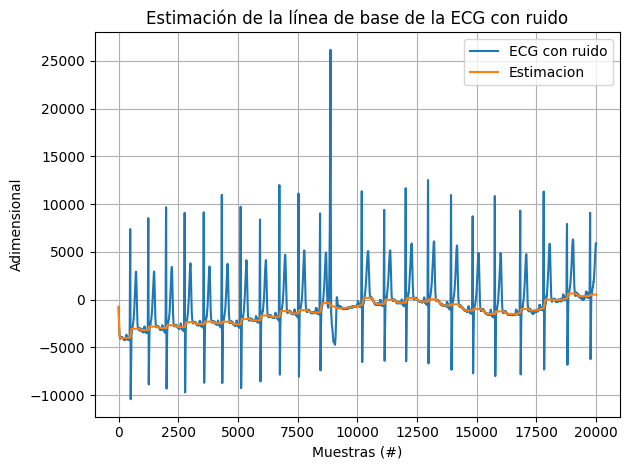

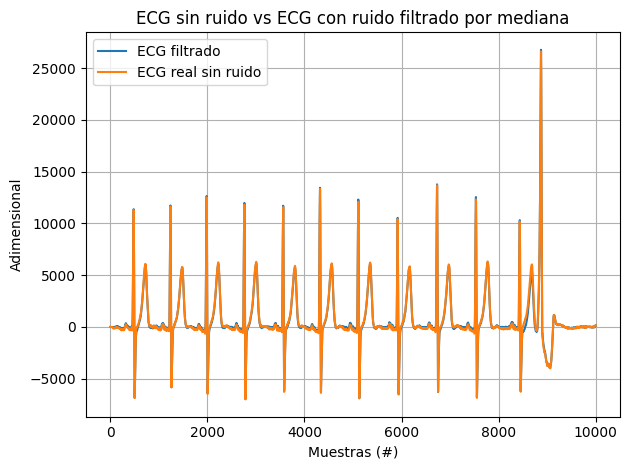

In [16]:
# Graficos
plt.figure()
plt.plot(ecg_one_lead[:20000], label='ECG con ruido')
plt.plot(b[:20000], label='Estimacion')
plt.title('Estimación de la línea de base de la ECG con ruido')
plt.ylabel('Adimensional')
plt.xlabel('Muestras (#)')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.figure()
plt.plot(ecg_limpia[:10000], label='ECG filtrado')
plt.plot(ecg_real[:10000], label='ECG real sin ruido')
plt.title('ECG sin ruido vs ECG con ruido filtrado por mediana')
plt.ylabel('Adimensional')
plt.xlabel('Muestras (#)')
plt.grid(True)
plt.legend()
plt.tight_layout()



Luego se buscaron zonas de interés para verificar el funcionamiento del filtro en regiones sin ruido y regiones con ruido.


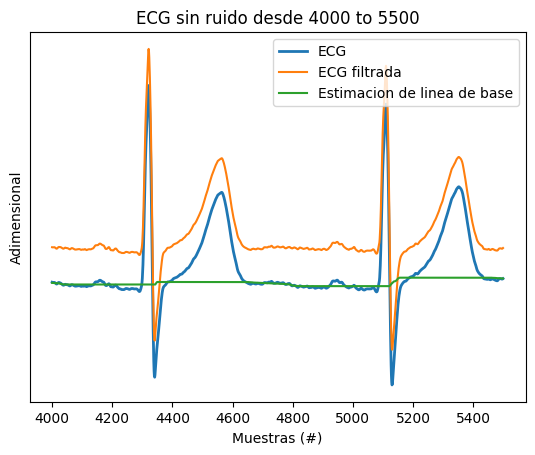

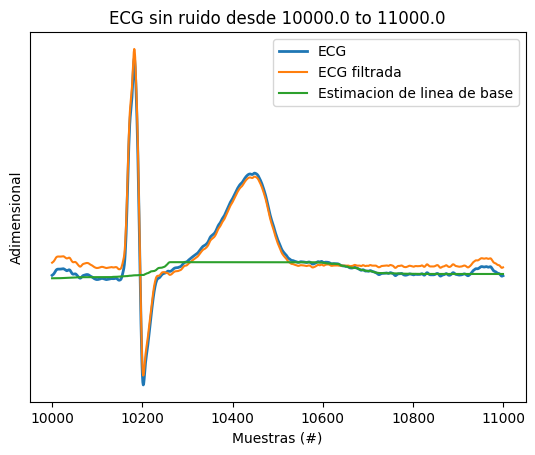

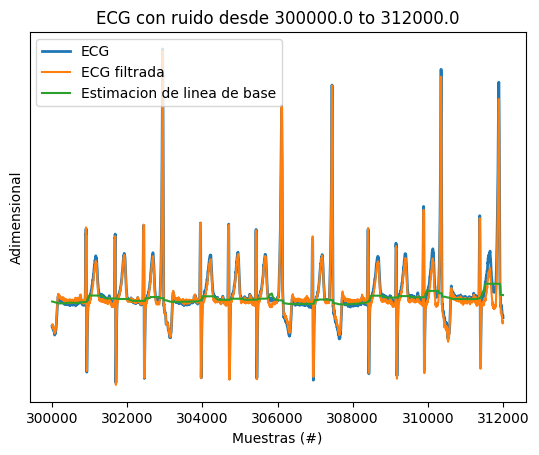

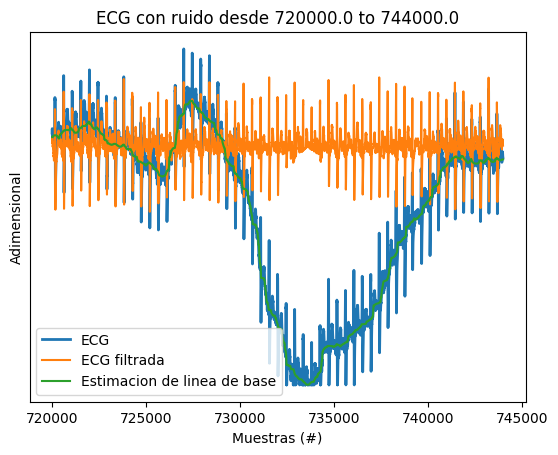

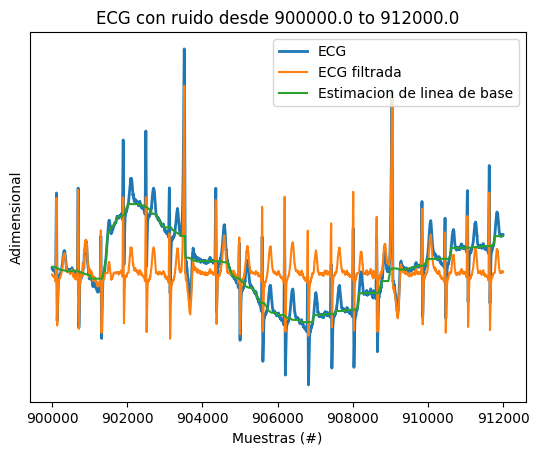

In [17]:
##################
## ECG sin ruido
##################

#################################
# Regiones de interés sin ruido #
#################################

cant_muestras = len(ecg_one_lead)

regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ecg_limpia[zoom_region], label='ECG filtrada')
    plt.plot(zoom_region, b[zoom_region], label='Estimacion de linea de base')
   
    plt.title('ECG sin ruido desde ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()
 
#################################
# Regiones de interés con ruido #
#################################
 
regs_interes = (
        np.array([5, 5.2]) *60*fs_ecg, # minutos a muestras
        np.array([12, 12.4]) *60*fs_ecg, # minutos a muestras
        np.array([15, 15.2]) *60*fs_ecg, # minutos a muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ecg_limpia[zoom_region], label='ECG filtrada')
    plt.plot(zoom_region, b[zoom_region], label='Estimacion de linea de base')
   
    plt.title('ECG con ruido desde ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()


El filtrado mediante doble mediana mostró un desempeño adecuado para la corrección de la línea de base en registros ECG. Las ventanas empleadas (201 y 601 muestras), equivalentes a aproximadamente 200 ms y 600 ms a la frecuencia de muestreo utilizada, resultan apropiadas para capturar variaciones lentas sin afectar la morfología de los complejos cardíacos. La primera mediana atenúa eficazmente los transitorios rápidos, como los complejos QRS, mientras que la segunda suaviza la envolvente obtenida, proporcionando una estimación robusta de la deriva de base.

Dado que el filtro de mediana es un operador no lineal, introduce un retraso variable que difiere del retardo fijo de un FIR lineal. Si bien esto no afecta la corrección de la línea de base, debe considerarse en aplicaciones que requieran una sincronización precisa de eventos, especialmente en análisis basados en la localización exacta de los picos. En conjunto, el método resulta efectivo y estable para eliminar artefactos de baja frecuencia sin distorsionar significativamente la señal útil.

A continuación se realizó la estimación de la línea de base a partir de puntos isoeléctricos reconstruidos mediante splines cúbicos de la manera detallada anteriormente.



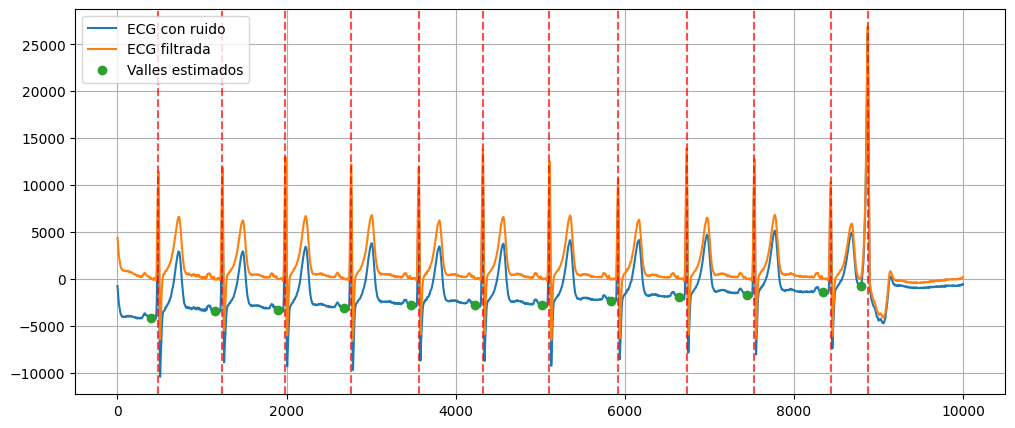

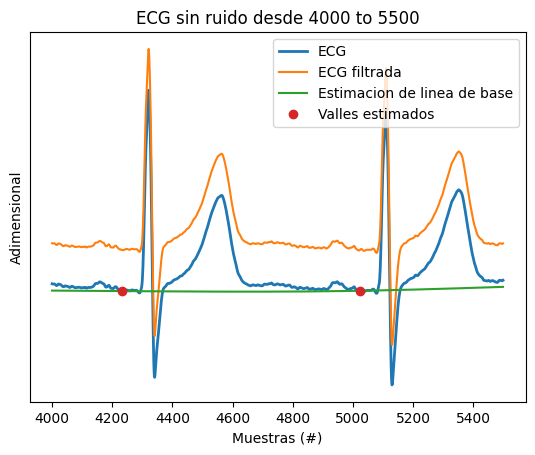

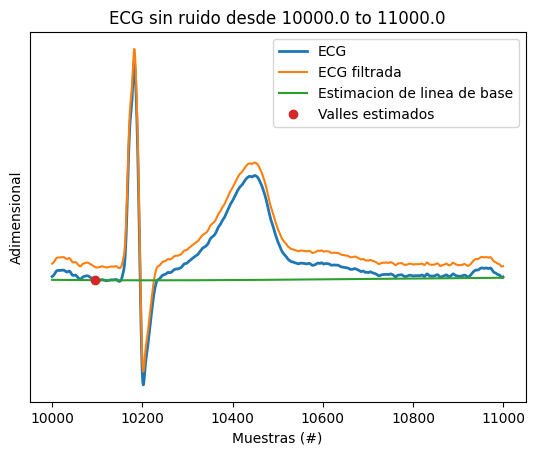

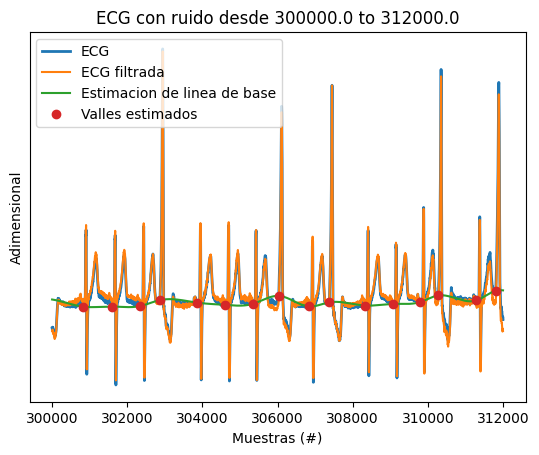

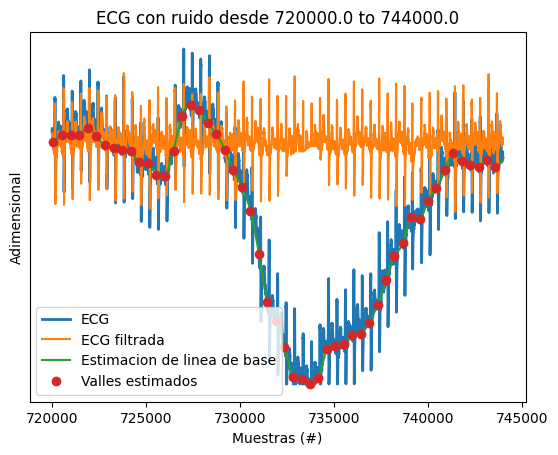

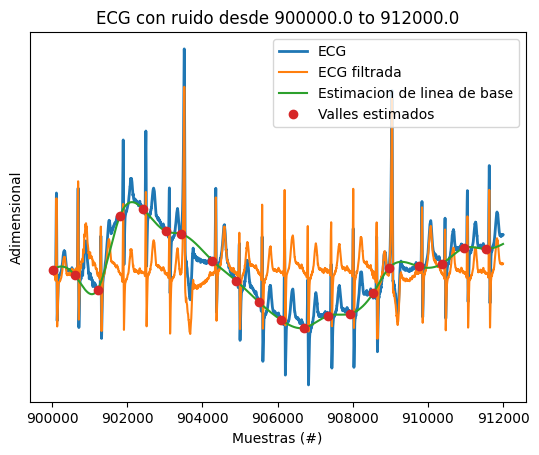

In [18]:
# INTERPOLACION MEDIANTE SPLINES CUBICOS
# Cargar detecciones
qrs_detections = mat_struct['qrs_detections'].flatten()
Q = len(qrs_detections)

# Cálculo de "valles"
valle = qrs_detections - 86
valle = valle[valle >= 0]  # evitar índices inválidos

ejey = ecg_one_lead[valle]

# Cubic spline para reconstrucción de la línea de base
cs = CubicSpline(valle, ejey)
b = cs(np.arange(N))

senal_limpia = ecg_one_lead - b

plt.figure(figsize=(12,5))

plt.plot(ecg_one_lead[:10000], label='ECG con ruido')
plt.plot(senal_limpia[:10000], label='ECG filtrada')

# Filtrar valles que están dentro del rango de ploteo
valle_en_rango = valle[valle < 10000]
ejey_en_rango = ejey[valle < 10000]
plt.plot(valle_en_rango[:12], ejey_en_rango[:12], 'o', label='Valles estimados')

# Dibujar líneas verticales para cada QRS
for q in qrs_detections[:12]:
    if q < 10000:  # Solo si está dentro del rango
        plt.axvline(x=q, linestyle='--', color='r', alpha=0.7)

plt.grid(True)
plt.legend()
plt.show()

##################
## ECG sin ruido
##################

#################################
# Regiones de interés sin ruido #
#################################

cant_muestras = len(ecg_one_lead)

regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, senal_limpia[zoom_region], label='ECG filtrada')
    plt.plot(zoom_region, b[zoom_region], label='Estimacion de linea de base')
    
    # Filtrar valles que están dentro de la región de zoom
    valle_en_zoom = valle[(valle >= ii[0]) & (valle < ii[1])]
    ejey_en_zoom = ejey[(valle >= ii[0]) & (valle < ii[1])]
    plt.plot(valle_en_zoom, ejey_en_zoom, 'o', label='Valles estimados')
   
    plt.title('ECG sin ruido desde ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()
 
#################################
# Regiones de interés con ruido #
#################################
 
regs_interes = (
        np.array([5, 5.2]) *60*fs_ecg, # minutos a muestras
        np.array([12, 12.4]) *60*fs_ecg, # minutos a muestras
        np.array([15, 15.2]) *60*fs_ecg, # minutos a muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, senal_limpia[zoom_region], label='ECG filtrada')
    plt.plot(zoom_region, b[zoom_region], label='Estimacion de linea de base')
    
    # CORRECCIÓN: Filtrar valles que están dentro de la región de zoom
    valle_en_zoom = valle[(valle >= ii[0]) & (valle < ii[1])]
    ejey_en_zoom = ejey[(valle >= ii[0]) & (valle < ii[1])]
    plt.plot(valle_en_zoom, ejey_en_zoom, 'o', label='Valles estimados')
    
    plt.title('ECG con ruido desde ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()


Este método mostró un desempeño adecuado y coherente con la naturaleza suave y de baja frecuencia del movimiento de línea de base en el ECG. El uso de los “valles” ubicados antes del complejo QRS permite seleccionar instantes donde la actividad eléctrica cardíaca es mínima, lo que brinda puntos de referencia razonablemente libres de componentes rápidos.

El spline cúbico genera una interpolación suave entre estos puntos, capturando eficazmente las variaciones lentas de la señal sin introducir oscilaciones artificiales de alta frecuencia. Comparado con el filtro de mediana, este método tiende a producir una línea de base más continua y diferenciable.

Sin embargo, su desempeño depende fuertemente de la correcta ubicación de los puntos isoeléctricos: si la estimación de los valles es inexacta o si el ECG presenta morfologías atípicas, la reconstrucción puede degradarse. Además, al usar una única muestra por latido, la capacidad del spline para seguir cambios bruscos en la interferencia de baja frecuencia es limitada.

Como último ejercicio se pidió aplicar un filtro adaptado al ECG para diseñar un detector de latidos. Para esto se partió desde un patrón representativo del complejo QRS y se emplea a modo de referencia. El filtro adaptado actúa comparando continuamente el ECG con ese patrón y genera una señal de salida cuya amplitud aumenta cuando la estructura presente en el ECG se asemeja al QRS de referencia. De esta manera, cada vez que ocurre un latido, la respuesta del sistema presenta un pulso que permite identificar su ubicación temporal. Una vez obtenida esta señal realzada, la detección se reduce a localizar los máximos que superan un umbral adecuado y se encuentren suficientemente separados (300ms), lo que permite discriminar cada latido de manera individual.

Este enfoque es útil porque concentra energía únicamente en los segmentos del ECG que coinciden con la forma del patrón, facilitando la identificación de latidos incluso cuando la señal contiene ruido o fluctuaciones de baja frecuencia. Además, al basarse en una plantilla específica, puede resaltar transitorios breves y consistentes como el QRS con alta sensibilidad.

Sin embargo, presenta limitaciones importantes. Su desempeño depende de que los latidos reales se parezcan al patrón elegido; si existe variabilidad morfológica significativa entre latidos o entre individuos, la respuesta del filtro se atenúa y pueden perderse detecciones. Asimismo, el método requiere seleccionar un umbral fijo, que puede no adaptarse bien a señales con variaciones de amplitud o con episodios de ruido impulsivo. Estas limitaciones hacen que el filtro adaptado funcione muy bien en contextos controlados, pero que requiera ajustes o etapas adicionales de procesamiento cuando se trabaja con señales muy cambiantes.

Para concluir con la tarea semanal, se aplicó este filtro a la señal. Para realizar la detección automática de los complejos QRS se utilizó un filtro adaptado (matched filter) construido a partir del patrón provisto en la variable qrs_pattern1. Antes de emplearlo, al patrón se le sustrajo su valor medio con el fin de centrarlo en cero, lo cual mejora la correlación con la señal. Posteriormente, dicho patrón se aplicó a la señal ECG mediante un filtrado lineal, lo que genera una nueva señal en la que los QRS aparecen como picos de gran amplitud. Esta señal se rectificó y se evaluó mediante find_peaks, imponiendo un umbral fijo y un intervalo mínimo entre detecciones para evitar múltiples marcaciones de un mismo latido.

Una vez obtenidas las detecciones, se compararon con las referencias qrs_detections. Para ello, se implementó una función que calcula la matriz de confusión emparejando cada detección con el QRS real más cercano dentro de una tolerancia temporal predefinida. A partir de estos emparejamientos se obtuvieron los valores de TP, FP y FN. Finalmente, se graficaron los TP, FP y FN sobre la señal para inspección visual.


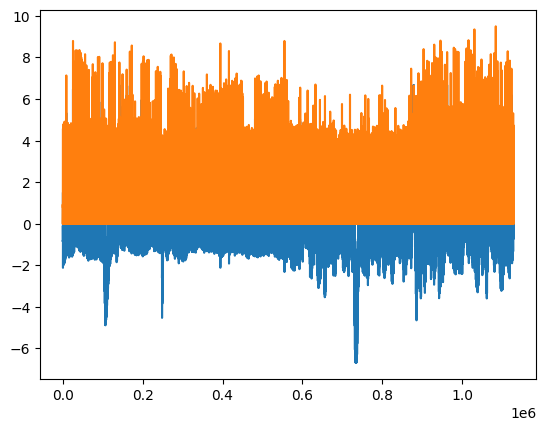

Matriz de Confusión:
           Predicho
           Sí    No
Real Sí:  [1902    1]
Real No:  [ 2    - ]

TP: 1902, FP: 2, FN: 1

Métricas:
Precisión: 0.999
Sensibilidad: 0.999
F1-score: 0.999


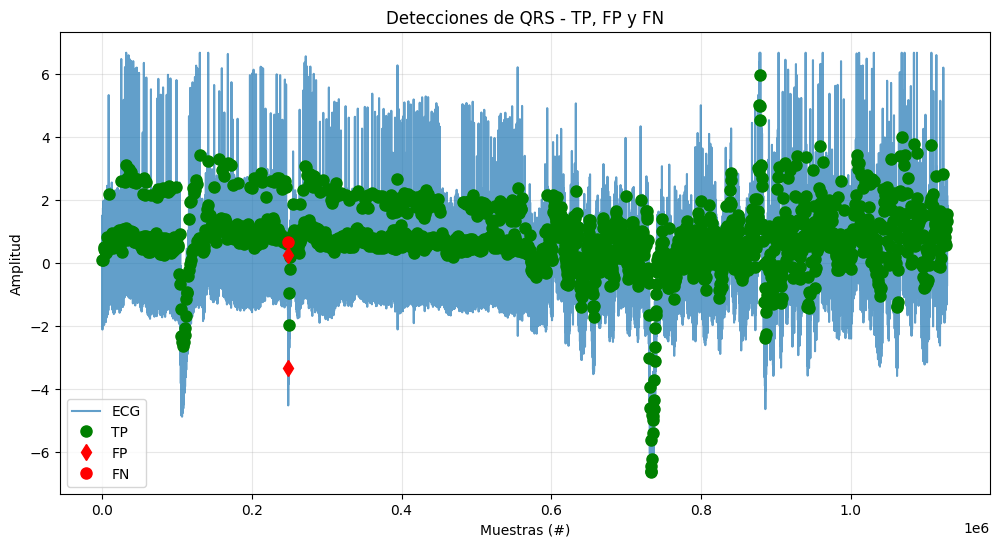

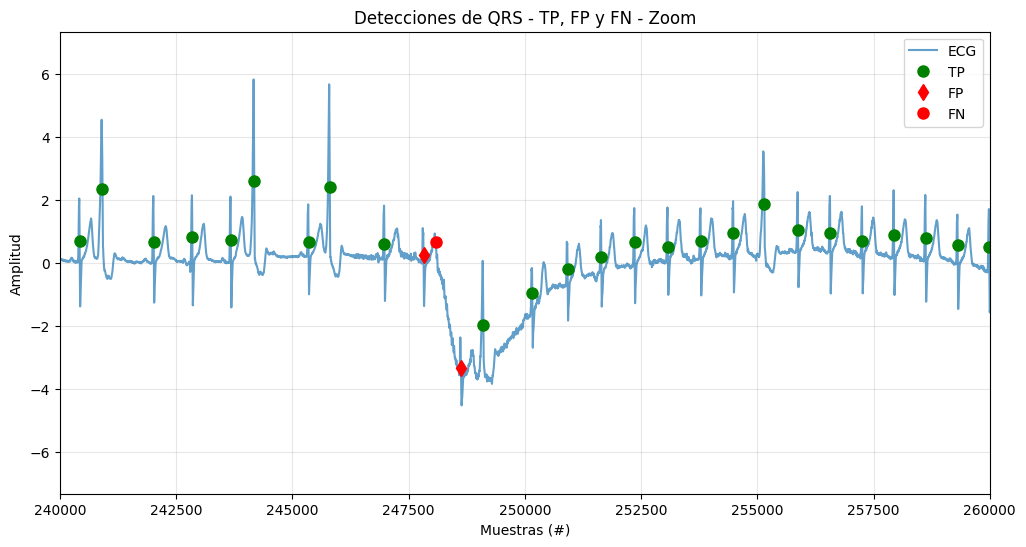

In [19]:
#%%
# FILTRO ADAPTADO

patron1 = mat_struct['qrs_pattern1']
patron2 = patron1.flatten() - np.mean(patron1) # le sacamos el valor medio al patron (valor medio nulo)

ecg_detection = signal.lfilter(b=patron2, a=1, x=ecg_one_lead)

delay = (len(patron2)-1) // 2

ecg_detection_abs = np.abs(ecg_detection)[delay:]

ecg_detection_abs = ecg_detection_abs / np.std(ecg_detection_abs)
# obtener detecciones QRS
qrs_det = mat_struct['qrs_detections']

mis_qrs, _ = signal.find_peaks(ecg_detection_abs, height=1.25, distance=300)

# Normalizamos las señales
ecg_one_lead = ecg_one_lead / np.std(ecg_one_lead)
# graficar normalizando
plt.figure()
plt.plot(ecg_one_lead)
plt.plot(ecg_detection_abs)
plt.show()

#%%
# EVALUACION DEL DESEMPEÑO
def matriz_confusion_qrs(mis_qrs, qrs_det, tolerancia_ms=150, fs=1000):
    """
    Calcula matriz de confusión para detecciones QRS usando solo NumPy y SciPy
    
    Parámetros:
    - mis_qrs: array con tiempos de tus detecciones (muestras)
    - qrs_det: array con tiempos de referencia (muestras)  
    - tolerancia_ms: tolerancia en milisegundos (default 150ms)
    - fs: frecuencia de muestreo (default 360 Hz)
    """
    
    # Convertir a arrays numpy
    mis_qrs = np.array(mis_qrs)
    qrs_det = np.array(qrs_det)
    
    # Convertir tolerancia a muestras
    tolerancia_muestras = tolerancia_ms * fs / 1000
    
    # Inicializar contadores
    TP = 0  # True Positives
    FP = 0  # False Positives
    FN = 0  # False Negatives
    
    # Arrays para marcar detecciones ya emparejadas
    mis_qrs_emparejados = np.zeros(len(mis_qrs), dtype=bool)
    qrs_det_emparejados = np.zeros(len(qrs_det), dtype=bool)
    
    # Encontrar True Positives (detecciones que coinciden dentro de la tolerancia)
    for i, det in enumerate(mis_qrs):
        diferencias = np.abs(qrs_det - det)
        min_diff_idx = np.argmin(diferencias)
        min_diff = diferencias[min_diff_idx]
        
        if min_diff <= tolerancia_muestras and not qrs_det_emparejados[min_diff_idx]:
            TP += 1
            mis_qrs_emparejados[i] = True
            qrs_det_emparejados[min_diff_idx] = True
    
    # False Positives (tus detecciones no emparejadas)
    tp_idx = np.where(mis_qrs_emparejados)[0]
    fp_idx = np.where(~mis_qrs_emparejados)[0]  # me dice en que posicion van a estar (que latidos son?)
    FP = np.sum(~mis_qrs_emparejados)
    
    # False Negatives (detecciones de referencia no emparejadas)
    fn_idx = np.where(~qrs_det_emparejados)[0]
    FN = np.sum(~qrs_det_emparejados)
    
    # Construir matriz de confusión
    matriz = np.array([
        [TP, FP],
        [FN, 0]  # TN generalmente no aplica en detección de eventos
    ])
    
    return matriz, TP, FP, FN, tp_idx, fp_idx, fn_idx

# Ejemplo de uso

matriz, tp, fp, fn, tp_idx, fp_idx, fn_idx = matriz_confusion_qrs(mis_qrs, qrs_det)

print("Matriz de Confusión:")
print(f"           Predicho")
print(f"           Sí    No")
print(f"Real Sí:  [{tp:2d}   {fn:2d}]")
print(f"Real No:  [{fp:2d}    - ]")
print(f"\nTP: {tp}, FP: {fp}, FN: {fn}")

# Calcular métricas de performance
if tp + fp > 0:
    precision = tp / (tp + fp)
else:
    precision = 0

if tp + fn > 0:
    recall = tp / (tp + fn)
else:
    recall = 0

if precision + recall > 0:
    f1_score = 2 * (precision * recall) / (precision + recall)
else:
    f1_score = 0

print(f"\nMétricas:")
print(f"Precisión: {precision:.3f}")
print(f"Sensibilidad: {recall:.3f}")
print(f"F1-score: {f1_score:.3f}") # punto medio entre los 2 pero mas parecido a la mas baja

# Gráfico principal con detecciones
plt.figure(figsize=(12, 6))
plt.plot(ecg_one_lead, label='ECG', alpha=0.7)
plt.plot(mis_qrs[tp_idx], ecg_one_lead[mis_qrs[tp_idx]], 'og', markersize=8, label='TP')
plt.plot(mis_qrs[fp_idx], ecg_one_lead[mis_qrs[fp_idx]], 'dr', markersize=8, label='FP')
plt.plot(qrs_det[fn_idx], ecg_one_lead[qrs_det[fn_idx]], 'or', markersize=8, label='FN')
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Detecciones de QRS - TP, FP y FN')
plt.xlabel('Muestras (#)')
plt.ylabel('Amplitud')
plt.show()


# Zoom en la zona con puntos rojos
plt.figure(figsize=(12, 6))
plt.plot(ecg_one_lead, label='ECG', alpha=0.7)
plt.plot(mis_qrs[tp_idx], ecg_one_lead[mis_qrs[tp_idx]], 'og', markersize=8, label='TP')
plt.plot(mis_qrs[fp_idx], ecg_one_lead[mis_qrs[fp_idx]], 'dr', markersize=8, label='FP')
plt.plot(qrs_det[fn_idx], ecg_one_lead[qrs_det[fn_idx]], 'or', markersize=8, label='FN')
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Detecciones de QRS - TP, FP y FN - Zoom')
plt.xlabel('Muestras (#)')
plt.ylabel('Amplitud')
plt.xlim([240000,260000])
plt.show()


En conjunto, esta metodología permite cuantificar de forma completa el desempeño del detector: un número elevado de TP junto con un bajo número de FP indica que el filtro adaptado responde adecuadamente al patrón del QRS, mientras que la presencia de FN revela latidos omitidos por umbrales altos o variabilidad morfológica en la señal. La combinación de métricas y análisis visual confirma si los parámetros elegidos (patrón, umbral y distancia mínima entre picos) resultan apropiados para una detección robusta.

La matriz de confusión obtenida muestra un comportamiento particular del detector basado en filtro adaptado. El sistema logra identificar correctamente 1902 de los 1903 complejos QRS presentes, generando únicamente 1 falso negativo, lo que implica que prácticamente no omite latidos reales. Esto se refleja en la sensibilidad de 0.999, indicando que el detector responde de manera muy eficaz ante la presencia de un QRS, aun cuando la estructura de la señal pueda  introducir variabilidad.

Además, el método produce únicamente 2 falsos positivos, es decir, marca muy pocos eventos que no corresponden a latidos reales. Esta tendencia se manifiesta claramente en la precisión de 0.999, que indica que prácticamente todos los eventos detectados corresponden a QRS verdaderos. La combinación entre una sensibilidad muy elevada y una precisión casi perfecta genera un F1-score de 0.999, valor que resume un desempeño global excelente.

En conjunto, los resultados evidencian que el filtro adaptado es extremadamente efectivo tanto para no dejar QRS sin detectar como para evitar identificaciones erróneas. La normalización de la señal previa a la utilización de find_peaks demostró ser crucial para reducir drásticamente los falsos positivos. Esto confirma que el patrón utilizado responde específicamente a los complejos QRS y muestra baja susceptibilidad al ruido de la señal.




Por último, se incorporó un apartado BONUS cuyo objetivo fue evaluar el desempeño y las diferencias entre dos enfoques para la corrección de línea base del ECG, basados en el uso de interpolación y diezmado. Para ello se tomó la señal completa con su línea de base desplazada respecto de la original y se aplicaron los distintos métodos con el fin de analizar cómo estos afectan la estimación del baseline y hasta qué punto pueden alterar o preservar el comportamiento temporal real de la señal.

El diezmado reduce la cantidad de muestras por segundo, lo que implica una disminución de la resolución temporal. Esto resulta útil cuando se busca reducir el volumen de datos o acelerar las operaciones computacionales. En este contexto, al diezmar la señal se espera conservar adecuadamente las componentes de baja frecuencia asociadas al movimiento de la línea de base, aunque se pierdan variaciones rápidas y pequeñas.

Por el contrario, la interpolación incrementa artificialmente el número de muestras entre valores reales, aumentando la resolución temporal sin introducir información fisiológica nueva. Se espera que este procedimiento proporcione una representación más suave en el dominio temporal y un espectro frecuencial con mayor resolución en el eje de frecuencias, sin generar nuevas componentes reales.

Finalmente, se corrigió la línea base del ECG utilizando dos enfoques. El primero consistió en aplicar un filtro de mediana directamente sobre la señal original muestreada a 1000 Hz, estimando así la línea base con máxima resolución temporal, aunque con mayor costo computacional. En el segundo método se trabajó sobre la misma señal previamente diezmada a 125 Hz; a esta se le aplicó también un filtro de mediana para estimar su línea base, la cual luego fue interpolada para volver a 1000 Hz. Este enfoque permite disminuir significativamente el tiempo de procesamiento, manteniendo una estimación razonablemente precisa de la base y logrando una mejora en eficiencia computacional.


COMPARACIÓN DE RESULTADOS

Tiempo método directo 1000 Hz: 0.1923 segundos
Tiempo método resample_poly: 0.0622 segundos
Aceleración obtenida: 3.09x


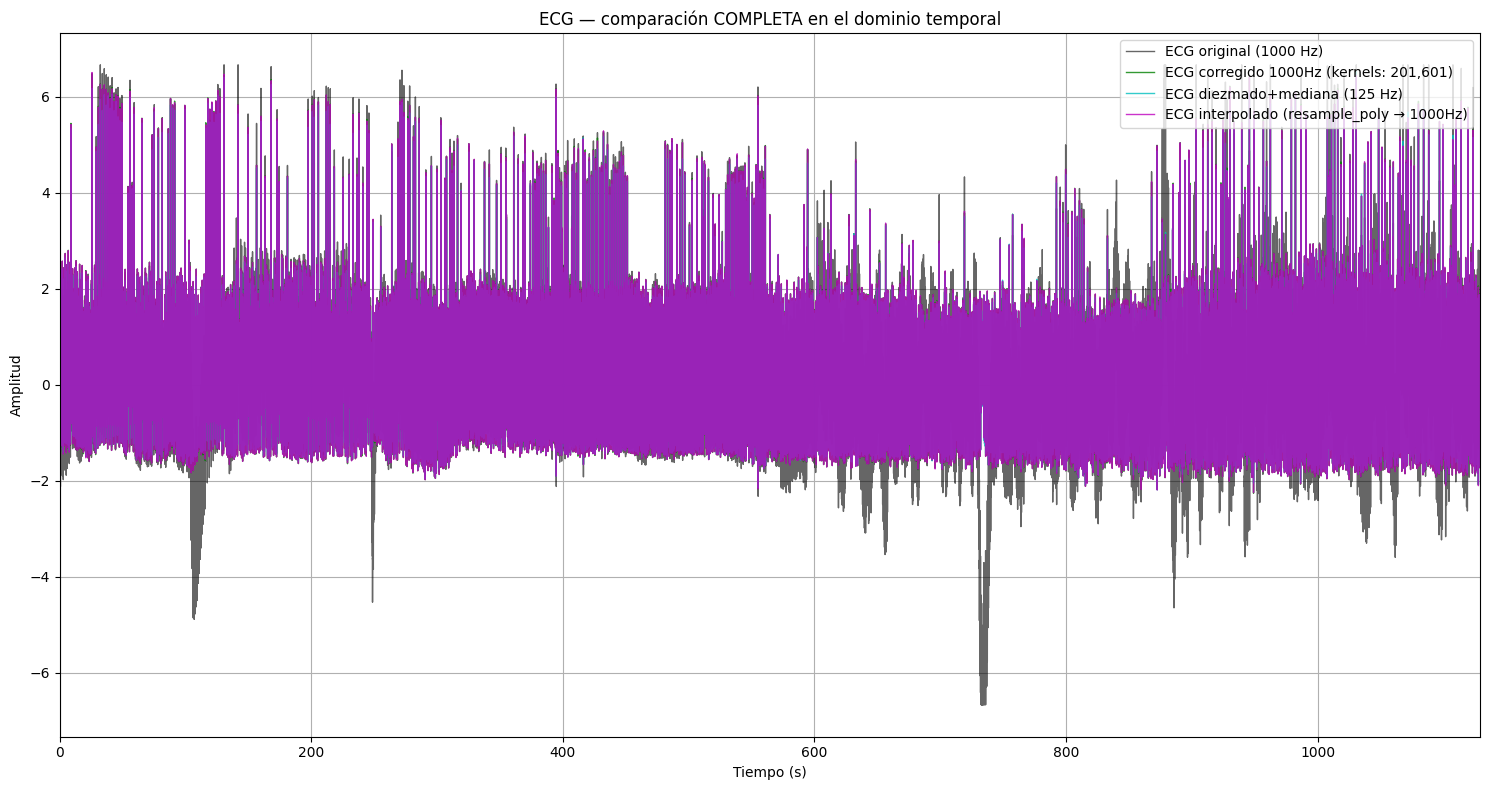

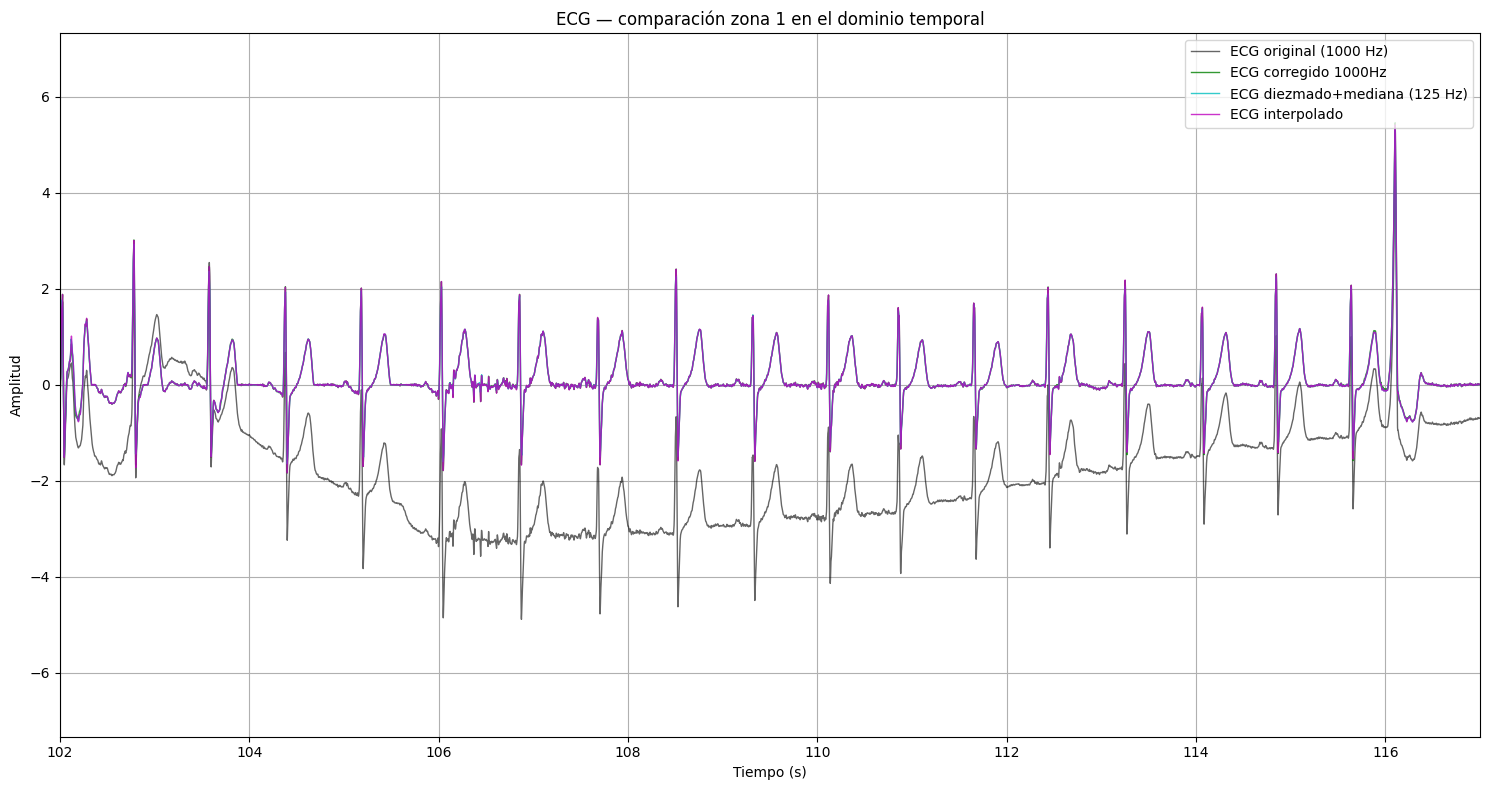

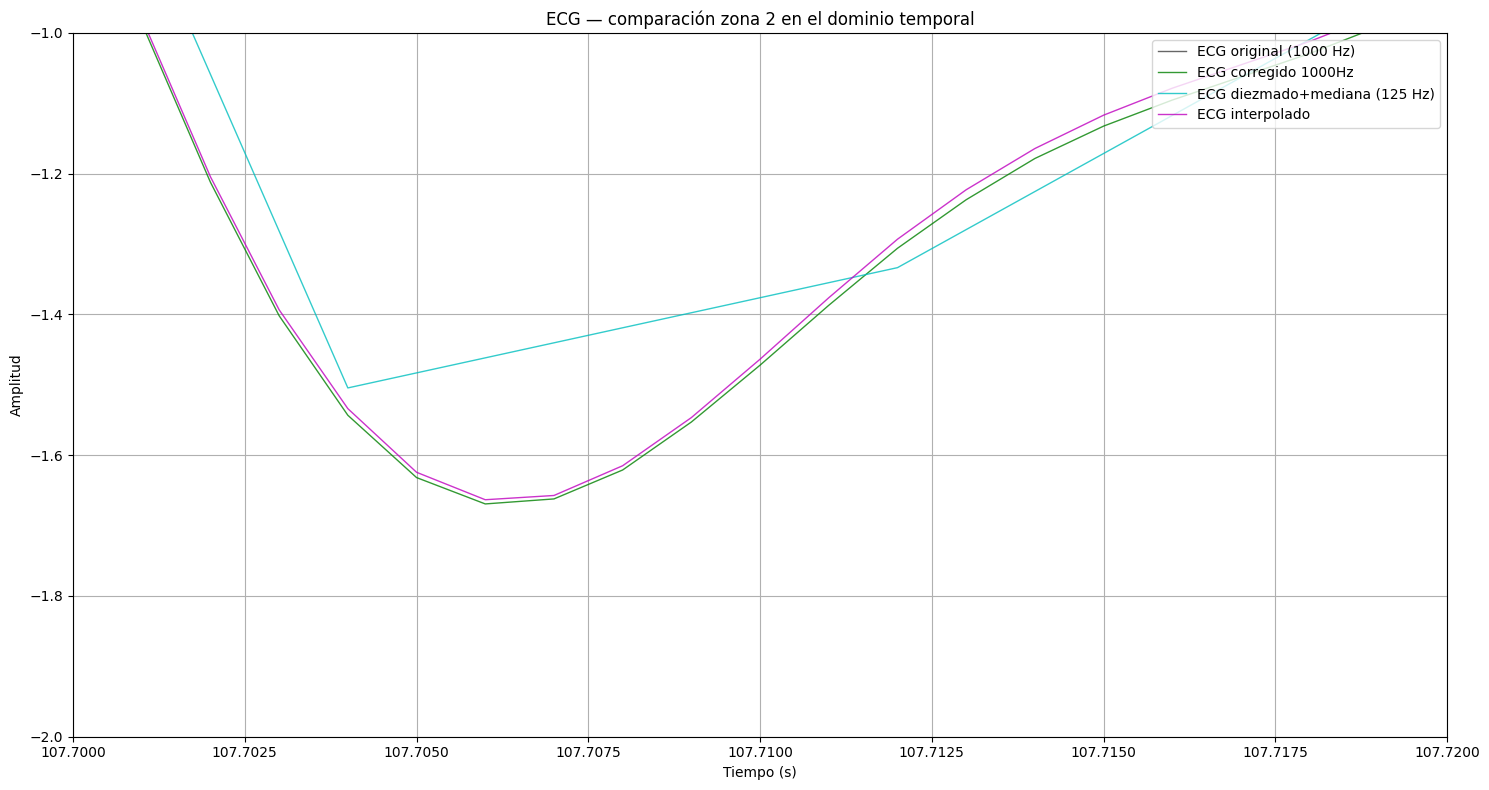

In [27]:
#%%
# =============================================================================
# BONUS: COMPARACIÓN DE TIEMPOS DE EJECUCIÓN - ESTIMACIÓN DE LÍNEA BASE
# =============================================================================

import time
from scipy import signal

# Parámetros de muestreo originales
fs_original = 1000  # Frecuencia de muestreo completa (1000 Hz)
fs_diezmada = 125   # Frecuencia luego de diezmado
factor_diezmado = fs_original // fs_diezmada  # 8

# ==========================================================================  
# TRABAJO SOBRE LA TOTALIDAD DE LA SEÑAL  
# ==========================================================================
ecg_total = ecg_one_lead
N = len(ecg_total)
t_total = np.arange(N) / fs_original


# -------------------------------------------------------------------------
# MÉTODO 1: FILTRACIÓN A FREC COMPLETA - 1000 Hz
# -------------------------------------------------------------------------

tiempo_inicio_1khz = time.time()

kernel1_1khz = 201    
kernel2_1khz = 601   

resul1_mediana = signal.medfilt(ecg_total, kernel_size=kernel1_1khz)  
linea_base_1khz = signal.medfilt(resul1_mediana, kernel_size=kernel2_1khz) 
ecg_limpio_1khz = ecg_total - linea_base_1khz

tiempo_fin_1khz = time.time()
tiempo_1khz = tiempo_fin_1khz - tiempo_inicio_1khz

# -------------------------------------------------------------------------
# MÉTODO 2: DIEZMADO + MEDIANA + INTERPOLACIÓN 
# -------------------------------------------------------------------------

tiempo_inicio_125hz = time.time()

# 1) Diezmado polyphase
ecg_diezmado = signal.resample_poly(ecg_total, up=1, down=factor_diezmado)
t_diezmado = np.arange(len(ecg_diezmado)) / fs_diezmada

# 2) Mediana sobre señal diezmada
# Calcular kernels equivalentes escalados para que se pueda tener una representación temporal correcta

kernel1_125hz = max(3, kernel1_1khz // factor_diezmado) #pone un valor minimo de 3 para garantizar que se calcule bien la mediana
kernel2_125hz = max(3, kernel2_1khz // factor_diezmado)

# Asegurar que sean impares
if kernel1_125hz % 2 == 0: kernel1_125hz += 1
if kernel2_125hz % 2 == 0: kernel2_125hz += 1


# Aplica filtro 
resul1_mediana_125hz = signal.medfilt(ecg_diezmado, kernel_size=kernel1_125hz)
linea_base_125hz = signal.medfilt(resul1_mediana_125hz, kernel_size=kernel2_125hz)

# Señal diezmada luego de la corrección
#la uso para la comparación gráfica.
ecg_diezmado_mediana = ecg_diezmado - linea_base_125hz

# 3) Interpolación de la línea base a 1000 Hz
#interpolo por el mismo factor de diezmado para volver a frecuencia original
linea_base_interpolada = signal.resample_poly(linea_base_125hz, up=factor_diezmado, down=1)

# Ajustar longitud por si hay diferencias por redondeo
if len(linea_base_interpolada) > N:
    linea_base_interpolada = linea_base_interpolada[:N]
elif len(linea_base_interpolada) < N:
    # Rellenar con el último valor si es más corta
    linea_base_interpolada = np.pad(linea_base_interpolada, (0, N - len(linea_base_interpolada)), mode='edge')

# Señal corregida final a 1000 Hz
ecg_limpio_125hz = ecg_total - linea_base_interpolada

tiempo_125hz = time.time() - tiempo_inicio_125hz

# -------------------------------------------------------------------------
# COMPARACIÓN DE MÉTODOS
# -------------------------------------------------------------------------
print("\n" + "="*50)
print("COMPARACIÓN DE RESULTADOS")
print("="*50)

print(f"\nTiempo método directo 1000 Hz: {tiempo_1khz:.4f} segundos")
print(f"Tiempo método resample_poly: {tiempo_125hz:.4f} segundos")
print(f"Aceleración obtenida: {tiempo_1khz/tiempo_125hz:.2f}x")



# =============================================================================
# VISUALIZACIÓN FINAL — TODA LA SEÑAL
# =============================================================================

plt.figure(figsize=(15, 8))
plt.plot(t_total, ecg_total, 'k', linewidth=1, alpha=0.6, label="ECG original (1000 Hz)")
plt.plot(t_total, ecg_limpio_1khz, 'g', linewidth=1, alpha=0.8, label=f"ECG corregido 1000Hz (kernels: {kernel1_1khz},{kernel2_1khz})")
plt.plot(t_diezmado, ecg_diezmado_mediana, 'c', linewidth=1, alpha=0.8,  label=f"ECG diezmado+mediana ({fs_diezmada} Hz)")
plt.plot(t_total, ecg_limpio_125hz, 'm', linewidth=1, alpha=0.8, label="ECG interpolado (resample_poly → 1000Hz)")
plt.title("ECG — comparación COMPLETA en el dominio temporal")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.legend(loc='upper right')
plt.xlim(t_total[0], t_total[-1])
plt.tight_layout()
plt.show()

# =============================================================================
# VISUALIZACIÓN 1 — PRIMERA COMPARACIÓN INTERESANTE
# =============================================================================

plt.figure(figsize=(15, 8))

plt.plot(t_total, ecg_total, 'k', linewidth=1, alpha=0.6, label="ECG original (1000 Hz)")
plt.plot(t_total, ecg_limpio_1khz, 'g', linewidth=1, alpha=0.8, label=f"ECG corregido 1000Hz")
plt.plot(t_diezmado, ecg_diezmado_mediana, 'c', linewidth=1, alpha=0.8, label=f"ECG diezmado+mediana ({fs_diezmada} Hz)")
plt.plot(t_total, ecg_limpio_125hz, 'm', linewidth=1, alpha=0.8, label="ECG interpolado")
plt.title("ECG — comparación zona 1 en el dominio temporal")
plt.xlabel("Tiempo (s)")
plt.xlim(102,117)
plt.ylabel("Amplitud")
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# =============================================================================
# VISUALIZACIÓN 2 — SEGUNDA COMPARACIÓN INTERESANTE
# =============================================================================

plt.figure(figsize=(15, 8))
plt.plot(t_total, ecg_total, 'k', linewidth=1, alpha=0.6, label="ECG original (1000 Hz)")
plt.plot(t_total, ecg_limpio_1khz, 'g', linewidth=1, alpha=0.8, label="ECG corregido 1000Hz")
plt.plot(t_diezmado, ecg_diezmado_mediana, 'c', linewidth=1, alpha=0.8, label=f"ECG diezmado+mediana ({fs_diezmada} Hz)")
plt.plot(t_total, ecg_limpio_125hz, 'm', linewidth=1, alpha=0.8, label="ECG interpolado")
plt.title("ECG — comparación zona 2 en el dominio temporal")
plt.xlabel("Tiempo (s)")
plt.xlim(107.70,107.72)
plt.ylim(-2,-1)
plt.ylabel("Amplitud")
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


Los resultados muestran que el método basado en diezmado reduce notablemente el tiempo de ejecución, ya que procesa ocho veces menos muestras al aplicar el filtro de mediana. Esto implica un ahorro computacional directo, reflejado en una mejora significativa en el rendimiento. Sin embargo, esta ventaja tiene un costo ya que al estimar la línea base con menor resolución temporal, se pierde parte de la información asociada a variaciones rápidas, mientras que las componentes lentas vinculadas al desplazamiento de la línea de base se preservan correctamente. La interpolación cúbica contribuye a reconstruir la tendencia general de la señal, suavizando la transición entre muestras.

En el último gráfico puede observarse que, al incorporar la etapa de interpolación, la señal resultante se ajusta mejor a la variación real del ECG en el tiempo. En cambio, cuando se aplica la mediana sobre la señal diezmada sin realizar interpolación posterior, el resultado muestra segmentos más lineales y rígidos, que no reflejan con la misma continuidad el comportamiento temporal de la señal original.

Además, es importante destacar que en el proceso de diezmado no se reduce la cantidad de muestras de forma directa, sino que primero se aplica un filtrado pasa bajos sobre la señal original antes de descartar muestras. Esto evita que las variaciones rápidas queden mal representadas en la versión diezmada. En el caso puntual del código utilizado, la función signal.resample_poly incorpora internamente este filtrado previo como parte del algoritmo, de modo que la atenuación de contenido rápido ocurre antes de que se reduzca la cantidad de muestras.

Del mismo modo, durante la interpolación la función expande primero la señal generando nuevas muestras intermedias, y luego aplica un filtrado que suaviza la curva resultante.

### CONCLUSIÓN
A lo largo del trabajo se analizaron distintos métodos destinados al preprocesamiento y detección de complejos QRS en señales ECG, evaluando tanto su desempeño como sus limitaciones. En primer lugar, la corrección de la línea de base mediante doble filtrado de mediana mostró ser una estrategia robusta para eliminar variaciones lentas sin afectar la morfología cardíaca. Las ventanas empleadas permitieron captar adecuadamente la deriva sin introducir distorsiones relevantes, y la comparación con la señal original confirmó que el procedimiento preserva la integridad de los complejos QRS. No obstante, al tratarse de un método no lineal, se observó la presencia de retardos que deben considerarse en aplicaciones que requieren sincronización precisa.

Posteriormente, se aplicó una segunda estrategia de estimación de la línea de base basada en splines cúbicos ajustados a puntos isoeléctricos. Este método produjo una reconstrucción suave y diferenciable, con un comportamiento más continuo que el filtro de mediana, aunque dependió fuertemente de la correcta identificación de los valles previos al QRS. Su sensibilidad ante variaciones morfológicas o errores en la selección de estos puntos constituye su principal limitación, especialmente en señales con ruido o latidos anómalos.

Otro aspecto relevante fue la implementación de técnicas de diezmado e interpolación durante el preprocesamiento. El diezmado permitió trabajar temporalmente con una versión reducida de la señal, disminuyendo el costo computacional y acelerando el procesamiento durante la estimación de la línea de base. Posteriormente, la interpolación a la frecuencia original permitió reconstruir la señal corregida sin pérdida de información relevante, asegurando que la resolución temporal y la forma característica de los complejos QRS se mantuvieran adecuadamente. Este enfoque demostró ser eficiente desde el punto de vista computacional.

Finalmente, se implementó un detector de latidos basado en un filtro adaptado, mediante el cual, a partir de la normalización y la comparación con un patrón representativo, se logró identificar los complejos QRS del ECG de manera muy efectiva.
